In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt 
import sklearn
import pandas as pd
from keras.api.models import Sequential
from keras.api.layers import Flatten, Dense, Conv2D, MaxPooling2D
from keras.api.utils import to_categorical

In [2]:
data = pd.read_csv("Datasets/hmnist_28_28_RGB.csv")
data.head(5)

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2
2,192,138,153,200,145,163,201,142,160,206,...,167,129,143,159,124,142,136,104,117,2
3,38,19,30,95,59,72,143,103,119,171,...,44,26,36,25,12,17,25,12,15,2
4,158,113,139,194,144,174,215,162,191,225,...,209,166,185,172,135,149,109,78,92,2


In [9]:
print(data.info(), "\n")
print(data.shape, "\n")
print(data["label"].value_counts(), "\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Columns: 2353 entries, pixel0000 to label
dtypes: int64(2353)
memory usage: 179.8 MB
None 

(10015, 2353) 

label
4    6705
6    1113
2    1099
1     514
0     327
5     142
3     115
Name: count, dtype: int64 



In [12]:
imagen = data.drop(columns= "label")
imagen = np.array(imagen).reshape(imagen.shape[0], 28, 28, 3)

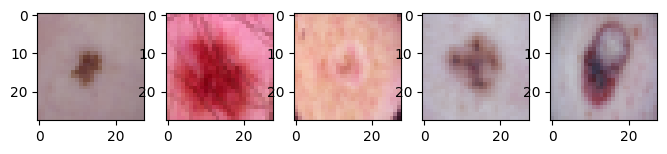

In [19]:
plt.figure(figsize = (8,8))
for i in range(5):
    num = np.random.randint(0,8000)
    plt.subplot(1,5,i+1)
    plt.imshow(imagen[num].reshape(28,28,3))
plt.show()
#Las imágenes son para analiza cancer de piel

In [51]:
num_clases = len(data["label"].unique())

In [52]:
x = data.drop(columns = "label").values
y = data["label"]

In [53]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [54]:
le = LabelEncoder()

In [55]:
y = le.fit_transform(y)
y = to_categorical(y, num_classes=num_clases)

In [56]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)

In [57]:
x_train = x_train.reshape(-1,28,28,3).astype("float32")/255

In [58]:
x_test = x_test.reshape(-1,28,28,3).astype("float32")/255

In [59]:
model = Sequential()

model.add(Conv2D(64, (3,3), activation = "relu", input_shape = (28,28,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation = "relu", input_shape = (28,28,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation = "relu", input_shape = (28,28,3)))
model.add(MaxPooling2D((1,1)))

model.add(Flatten())
model.add(Dense(128, activation = "relu"))

model.add(Dense(num_clases, activation= "softmax"))

C:\Users\Juan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
model.compile(optimizer = "adam", 
              loss = "categorical_crossentropy", 
              metrics=["accuracy"])

In [61]:
parada = tf.keras.callbacks.EarlyStopping(monitor = "loss", patience = 3)

In [62]:
story = model.fit(x_train, y_train, 
                  epochs = 50, 
                  batch_size = 64, 
                  callbacks = [parada])

Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6402 - loss: 1.1594
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6804 - loss: 0.9216
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6879 - loss: 0.8861
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6935 - loss: 0.8323
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7024 - loss: 0.8055
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7177 - loss: 0.7669
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7151 - loss: 0.7638
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7331 - loss: 0.7177
Epoch 9/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7428 - loss: 0.6938
Epoch 10/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7472 - loss: 0.6852
Epoch 11/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7634 - loss: 0.6409
Epoch 12/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 

In [64]:
loss, accuracy = model.evaluate(x_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7425 - loss: 1.5549


In [65]:
accuracy 

0.7463804483413696

In [68]:
index = np.random.randint(1, 2000, 1)

In [69]:
y_pred_i = model.predict(x_train[index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


In [77]:
predict = np.argmax(y_pred_i)
predict

np.int64(6)

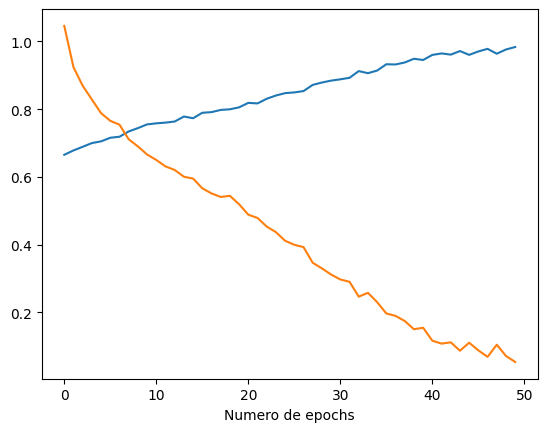

In [81]:
plt.plot(story.history["accuracy"])
plt.plot(story.history["loss"])
plt.xlabel("Numero de epochs")
plt.show()